# Modelos de Regresión Lineal
## Modelo con datos simulados
* y = a + b * x
* X : 100 valores distribuidos según una N(1.5, 2.5)
* Ye = 5 + 1.9 * x + e
* e estará distribuido según aun N(0, 0.8)

In [1]:
import pandas as pd
import numpy as np

In [36]:
x = 1.5 + 2.5 * np.random.randn(100)

In [37]:
res = 0 + 0.8 * np.random.randn(100)

In [38]:
y_pred = 5 + 1.9 * x

In [39]:
y_act = 5 + 1.9 * x + res

In [40]:
x_list = x.tolist()
y_pred_list = y_pred.tolist()
y_act_list = y_act.tolist()

In [41]:
data = pd.DataFrame(
    {
        "x": x_list,
        "y_actual": y_act_list,
        "y_prediccion": y_pred_list
    }
)

In [42]:
data.head()

,x,y_actual,y_prediccion
0,2.736331,10.526259,10.199028
1,4.792667,14.674944,14.106068
2,3.171948,10.806330,11.026701
3,1.413782,9.104460,7.686185
4,-2.206885,0.637500,0.806918


In [43]:
import matplotlib.pyplot as plt

In [44]:
y_mean = [np.mean(y_act) for i in range(1, len(x_list) + 1)]

Text(0.5,1,'Valor Actual vs Predicción')

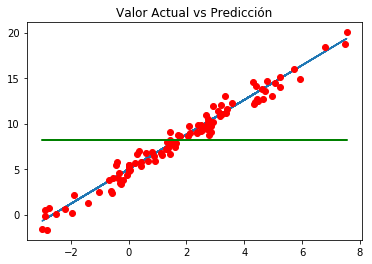

In [45]:
%matplotlib inline
plt.plot(x, y_pred)
plt.plot(x, y_act, "ro")
plt.plot(x, y_mean, "g")
plt.title("Valor Actual vs Predicción")

In [46]:
data["SSR"] = (data["y_prediccion"]-np.mean(y_act)) ** 2
data["SSD"] = (data["y_prediccion"]-data["y_actual"]) ** 2
data["SST"] = (data["y_actual"]-np.mean(y_act)) ** 2

In [47]:
data.head()

,x,y_actual,y_prediccion,SSR,SSD,SST
0,2.736331,10.526259,10.199028,4.056549,0.107080,5.481772
1,4.792667,14.674944,14.106068,35.059748,0.323620,42.120142
2,3.171948,10.806330,11.026701,8.075605,0.048564,6.871683
3,1.413782,9.104460,7.686185,0.248757,2.011505,0.845517
4,-2.206885,0.637500,0.806918,54.435211,0.028702,56.963853


In [48]:
SSR = sum(data["SSR"])
SSD = sum(data["SSD"])
SST = sum(data["SST"])

In [49]:
SSR

2013.9320432097381

In [50]:
SSD

56.96043941041907

In [51]:
SST

2056.4943983303315

In [52]:
R2 = SSR/SST
R2

0.9793034422290915

(array([ 5.,  3.,  7., 10., 14., 15., 20.,  9., 10.,  7.]),
 array([-1.68337711, -1.36171461, -1.04005211, -0.71838961, -0.39672711,
        -0.07506461,  0.24659789,  0.56826039,  0.88992289,  1.21158539,
         1.53324789]),
 <a list of 10 Patch objects>)

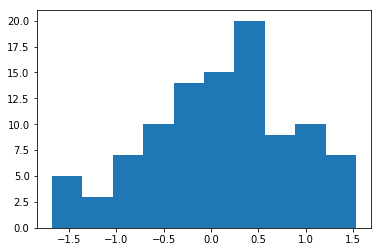

In [53]:
plt.hist(data["y_prediccion"]-data["y_actual"])

## Obteniendo la recta de regresión
* y = a +b * x
* sum((xi - x_m)*(y_i - y_m))/sum-8(xi-x_m)^2)
* a = y_m * x_m

In [54]:
x_mean = np.mean(data["x"])
y_mean = np.mean(data["y_actual"])
x_mean, y_mean

(1.7258634417867478, 8.184940491374036)

In [55]:
data["beta_n"] = (data["x"]-x_mean)*(data["y_actual"] - y_mean)
data["beta_d"] = (data["x"]-x_mean)**2

In [56]:
beta = sum(data["beta_n"])/sum(data["beta_d"])

In [57]:
alpha = y_mean - beta * x_mean

In [58]:
alpha, beta

(4.916081331688752, 1.8940427617500877)

El modelo lineal obtenido por regresión es: y = 4.877285594771255 + 1.9430022125596447  x

In [59]:
data["y_model"] = alpha + beta * data["x"]

In [60]:
data.head()

,x,y_actual,y_prediccion,SSR,SSD,SST,beta_n,beta_d,y_model
0,2.736331,10.526259,10.199028,4.056549,0.107080,5.481772,2.365825,1.021044,10.098809
1,4.792667,14.674944,14.106068,35.059748,0.323620,42.120142,19.903567,9.405286,13.993598
2,3.171948,10.806330,11.026701,8.075605,0.048564,6.871683,3.790751,2.091161,10.923887
3,1.413782,9.104460,7.686185,0.248757,2.011505,0.845517,-0.286965,0.097395,7.593844
4,-2.206885,0.637500,0.806918,54.435211,0.028702,56.963853,29.682184,15.466511,0.736147


In [61]:
SSR = sum((data["y_model"]-y_mean)**2)
SSD = sum((data["y_model"]-data["y_actual"])**2)
SST = sum((data["y_actual"]-y_mean)**2)

In [62]:
SSR, SSD, SST

(2000.441113385191, 56.05328494514068, 2056.494398330331)

In [64]:
R2 = SSR / SST
R2

0.9727432834289995

Text(0.5,1,'Valor Actual vs Predicción')

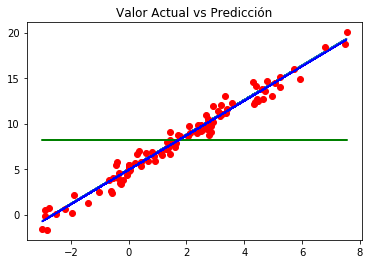

In [66]:
y_mean = [np.mean(y_act) for i in range(1, len(x_list) + 1)]
%matplotlib inline
plt.plot(data["x"], data["y_prediccion"])
plt.plot(data["x"], data["y_actual"], "ro")
plt.plot(data["x"], y_mean, "g")
plt.plot(data["x"], data["y_model"], "b")
plt.title("Valor Actual vs Predicción")